## 1. Реализовать алгоритм сортировки TimSort

Дисциплина: АиСД

Студент: Даньшина Василиса Ивановна

Группа: база

In [20]:
import time
import random
import matplotlib.pyplot as plt
import numpy as np
random.seed(42)
np.random.seed(42)

In [21]:
def timsort_simple(arr, key=None):
    """
    Упрощенная версия алгоритма Timsort без режима галопа

    ОПИСАНИЕ ДЛЯ ВОССТАНОВЛЕНИЯ:
    Timsort - гибридный стабильный алгоритм сортировки, который:
    1. Ищет естественные упорядоченные участки (runs) в массиве
    2. Дополняет короткие runs сортировкой вставками
    3. Сливает runs, поддерживая инварианты стека для гарантии O(n log n)
    4. Использует адаптивный подход - быстро работает на частично отсортированных данных

    ОСНОВНЫЕ ЭТАПЫ АЛГОРИТМА:
    1. Инициализация: копия массива, определение min_run
    2. Поиск runs: находим естественные упорядоченные участки
    3. Обработка runs: переворот убывающих, дополнение коротких
    4. Поддержание инвариантов: слияние runs при нарушении правил стека
    5. Финальное слияние: объединение всех оставшихся runs

    ВРЕМЕННАЯ СЛОЖНОСТЬ:
    - Лучший случай: O(n) - массив уже отсортирован
    - Средний случай: O(n log n)
    - Худший случай: O(n log n) - гарантируется инвариантами стека

    ПРОСТРАНСТВЕННАЯ СЛОЖНОСТЬ: O(n) - для временных копий при слиянии
    """

    if key is None:
        key = lambda x: x

    if len(arr) <= 1:
        return arr.copy()

    # Константа для минимального размера run (обычно 32, для учебных целей пусть будет 4)
    MIN_MERGE = 4

    # ===== БЛОК 1: БАЗОВЫЕ ФУНКЦИИ =====


    def find_run(arr, start):
        """
        Находит естественный упорядоченный участок (run) начиная с позиции start
        ОПИСАНИЕ ДЛЯ ВОССТАНОВЛЕНИЯ:
        Run - это максимальный участок массива, который уже упорядочен
        (возрастающий или убывающий). Использование естественных runs
        делает алгоритм адаптивным к частично отсортированным данным.
        АЛГОРИТМ:
        1. Если start в конце массива - вернуть single-элемент run
        2. Сравнить arr[start] с arr[start+1]
        3. Если arr[start] > arr[start+1]:
           - Искать убывающий run: продолжать пока arr[i] > arr[i+1]
           - Вернуть (end_pos, True) - потребуется переворот
        4. Иначе:
           - Искать неубывающий run: продолжать пока arr[i] <= arr[i+1]
           - Вернуть (end_pos, False) - переворот не нужен
        ВАЖНО: Используем <= для неубывающего случая, чтобы включить равные элементы
        в один run (важно для стабильности сортировки).
        ПРИМЕРЫ:
        - [1,2,3,4,1,2] начиная с 0 -> (4, False) - возрастающий [1,2,3,4]
        - [4,3,2,1,5,6] начиная с 0 -> (4, True) - убывающий [4,3,2,1]
        - [3,3,3,2,1] начиная с 0 -> (3, False) - равные элементы [3,3,3]
        """
        if start >= len(arr)-1:
            return len(arr), False

        if key(arr[start]) > key(arr[start + 1]):
            curr= start + 1
            while curr+ 1 < len(arr) and key(arr[curr]) > key(arr[curr + 1]):
                curr +=1
            return curr + 1, True
        else:
            curr= start + 1
            while curr+ 1 < len(arr) and key(arr[curr]) <= key(arr[curr + 1]):
                curr +=1
            return curr + 1, False

    def reverse_range(arr, start, end):
        """
        Переворачивает участок массива [start, end) на месте (in-place)

        ОПИСАНИЕ ДЛЯ ВОССТАНОВЛЕНИЯ:
        Используется для преобразования убывающих runs в возрастающие.
        Переворот выполняется эффективно за O(n/2) операций.
        АЛГОРИТМ:
        1. Установить два указателя: left = start, right = end - 1
        2. Пока left < right:
           - Поменять местами arr[left] и arr[right]
           - Сдвинуть указатели: left++, right--
        ПРИМЕР:
        reverse_range([1,2,3,4,5], 1, 4) -> [1,4,3,2,5]
        """
        left= start
        right = end-1
        while left < right:
            arr[left], arr[right] = arr[right], arr[left]
            left += 1
            right -= 1

    def binary_insertion_sort(arr, start, end):
        """
        Сортировка вставками с бинарным поиском позиции для вставки

        ОПИСАНИЕ ДЛЯ ВОССТАНОВЛЕНИЯ:
        Улучшенная версия сортировки вставками, которая использует
        бинарный поиск для нахождения позиции вставки вместо линейного.
        Эффективна для небольших массивов и почти отсортированных данных.

        ВРЕМЕННАЯ СЛОЖНОСТЬ:
        - Сравнения: O(n log n) - благодаря бинарному поиску
        - Сдвиги: O(n²) - все еще нужно сдвигать элементы
        - На практике быстрее обычной сортировки вставками для небольших массивов

        АЛГОРИТМ:
        1. Для каждого элемента i от start+1 до end:
           a) Сохранить current = arr[i]
           b) Найти позицию вставки в отсортированной части [start, i)
              используя бинарный поиск
           c) Сдвинуть элементы вправо от позиции вставки до i
           d) Вставить current в найденную позицию

        БИНАРНЫЙ ПОИСК позиции:
        - left = start, right = i
        - Пока left < right:
          - mid = (left + right) // 2
          - Если arr[mid] <= current: left = mid + 1 (ищем правее)
          - Иначе: right = mid (ищем левее)
        - Результат в left

        ВАЖНО: используем <= для поддержания стабильности сортировки
        """
        for i in range(start + 1, end):
            current = arr[i]
            left = start
            right= i

            while left < right:
                mid = (left + right)//2
                if key(arr[mid]) <= key(current):
                    left = mid + 1
                else:
                    right = mid

            for j in range(i, left, -1):
                arr[j] = arr[j-1]

            arr[left] = current

    # ===== БЛОК 2: СЛИЯНИЕ RUNS =====

    def merge_runs(arr, start1, len1, start2, len2):
        """
        Сливает два соседних отсортированных участка (runs) в один отсортированный

        ОПИСАНИЕ ДЛЯ ВОССТАНОВЛЕНИЯ:
        Основная операция Timsort - стабильное слияние двух runs.
        Использует дополнительную память для хранения копии одного из runs.

        ВРЕМЕННАЯ СЛОЖНОСТЬ: O(len1 + len2)
        ПРОСТРАНСТВЕННАЯ СЛОЖНОСТЬ: O(min(len1, len2)) - копируем меньший run

        АЛГОРИТМ:
        1. Создать временную копию левого run (обычно меньшего)
        2. Инициализировать три курсора:
           - cursor_left: для обхода временной копии
           - cursor_right: для обхода правого run в исходном массиве
           - dest: для записи результата в исходный массив
        3. Основной цикл слияния:
           - Сравнивать элементы из левого и правого run
           - Копировать меньший элемент в позицию dest
           - Продвигать соответствующий курсор
        4. Скопировать оставшиеся элементы левого run
           (правый run уже на своем месте)

        СТАБИЛЬНОСТЬ: при равенстве элементов берем из левого run (<=)

        ПРИМЕР:
        arr = [1,3,5, 2,4,6], start1=0, len1=3, start2=3, len2=3
        После слияния: [1,2,3,4,5,6]
        """
        print(f"  Слияние runs: [{start1}:{start1+len1}] + [{start2}:{start2+len2}]")
        print(f"  Данные: {arr[start1:start1+len1]} + {arr[start2:start2+len2]}")

        left_copy = arr[start1 : start1 + len1]
        cursor_left= 0
        cursor_right = start2
        dest = start1

        while cursor_left < len1 and cursor_right < start2 + len2:
            if key(left_copy[cursor_left]) <= key(arr[cursor_right]):
                arr[dest] = left_copy[cursor_left]
                cursor_left += 1
            else:
                arr[dest] = arr[cursor_right]
                cursor_right += 1
            dest += 1

        while cursor_left < len1:
            arr[dest] = left_copy[cursor_left]
            cursor_left += 1
            dest += 1


        print(f"  Результат: {arr[start1:start1 + len1 + len2]}")

    # ===== БЛОК 3: ПОДДЕРЖАНИЕ ИНВАРИАНТОВ СТЕКА =====

    def merge_collapse(arr, runs):
        """
        Поддерживает инварианты стека runs для гарантии временной сложности O(n log n)

        ОПИСАНИЕ ДЛЯ ВОССТАНОВЛЕНИЯ:
        Стек runs может расти неконтролируемо, что приведет к деградации
        до O(n²) времени. Инварианты обеспечивают сбалансированность
        слияний и гарантируют O(n log n).

        ИНВАРИАНТЫ СТЕКА (для runs с индексами ..., i-1, i, i+1):
        1. len(run[i-1]) > len(run[i]) + len(run[i+1])
        2. len(run[i]) > len(run[i+1])

        ОБОСНОВАНИЕ ИНВАРИАНТОВ:
        - Обеспечивают, что длины runs убывают не слишком быстро
        - Гарантируют глубину стека O(log n)
        - Предотвращают слияние очень разных по размеру runs

        АЛГОРИТМ:
        1. Пока стек содержит более одного run:
           a) Проверить инварианты для последних 2-3 runs
           b) Если инварианты нарушены:
              - Выбрать пару runs для слияния (меньшую из возможных)
              - Выполнить слияние
              - Обновить стек runs
           c) Иначе выйти из цикла

        СТРАТЕГИЯ ВЫБОРА runs для слияния:
        - Если нарушен инвариант 1: сливаем меньшую пару из двух возможных
        - Если нарушен инвариант 2: сливаем два последних run
        """
        while len(runs) > 1:
            if len(runs) >= 3:
                X, Y, Z = runs[-3], runs[-2], runs[-1]
                if X[1] <= Y[1] + Z[1]:
                    if X[1] < Z[1]:
                        merge_runs(arr, X[0], X[1], Y[0], Y[1])
                        runs[-3] = (X[0], X[1] + Y[1])
                        runs.pop(-2)
                    else:
                        merge_runs(arr, Y[0], Y[1], Z[0], Z[1])
                        runs[-2] = (Y[0], Y[1] + Z[1])
                        runs.pop(-1)
                elif Y[1] <= Z[1]:
                    merge_runs(arr, Y[0], Y[1], Z[0], Z[1])
                    runs[-2] = (Y[0], Y[1] + Z[1])
                    runs.pop(-1)
                else:
                    break
            else:
                Y, Z = runs[-2], runs[-1]
                if Y[1] < Z[1]:
                    merge_runs(arr, Y[0], Y[1], Z[0], Z[1])
                    runs[-2] = (Y[0], Y[1] + Z[1])
                    runs.pop(-1)
                else:
                    break

    def force_merge_all(arr, runs):
        """
        Принудительно сливает все оставшиеся runs в стеке справа налево

        ОПИСАНИЕ ДЛЯ ВОССТАНОВЛЕНИЯ:
        После обработки всех элементов массива в стеке могут остаться
        несколько runs. Их нужно слить в правильном порядке для получения
        финального отсортированного массива.

        АЛГОРИТМ:
        1. Пока в стеке больше одного run:
           a) Взять два последних run из стека
           b) Слить их с помощью merge_runs
           c) Заменить эти два run одним объединенным
           d) Удалить последний элемент стека

        ПОРЯДОК СЛИЯНИЯ: справа налево (последние runs первыми)
        Это важно для поддержания стабильности сортировки.

        ПРИМЕР:
        Стек: [(0,3), (3,4), (7,2)]
        1) Слить (3,4) и (7,2) -> [(0,3), (3,6)]
        2) Слить (0,3) и (3,6) -> [(0,9)]
        """
        while len(runs) > 1:
            Y= runs[-2]
            Z = runs[-1]
            merge_runs(arr, Y[0], Y[1], Z[0], Z[1])
            runs[-2] = (Y[0], Y[1] + Z[1])
            runs.pop(-1)

    # ===== ОСНОВНОЙ АЛГОРИТМ =====
    """
    ГЛАВНЫЙ ЦИКЛ TIMSORT:

    1. ИНИЦИАЛИЗАЦИЯ:
       - Создать копию исходного массива
       - Вычислить минимальную длину run
       - Инициализировать пустой стек runs

    2. ОСНОВНОЙ ЦИКЛ (пока не обработаны все элементы):
       a) Найти следующий естественный run
       b) Если run убывающий - перевернуть его
       c) Если run короткий - дополнить сортировкой вставками
       d) Добавить run в стек
       e) Проверить и поддержать инварианты стека

    3. ФИНАЛИЗАЦИЯ:
       - Слить все оставшиеся runs в стеке
       - Вернуть отсортированный массив

    P.S. Уже реализовано
    """

    print(f"Упрощенный Timsort для массива: {arr}")

    # Создаем рабочую копию
    result = arr.copy()
    n = len(result)

    # Вычисляем минимальную длину run
    min_run = min(n, MIN_MERGE)
    print(f"Минимальная длина run: {min_run}")

    # Стек runs: каждый элемент - кортеж (start, length)
    runs = []
    i = 0

    print(f"\nПоиск и обработка runs:")

    while i < n:
        # Находим естественный run
        run_end, need_reverse = find_run(result, i)

        print(f"\n--- Run #{len(runs) + 1} ---")
        print(f"Позиция: {i}-{run_end}, длина: {run_end - i}")
        print(f"Данные: {result[i:run_end]}")

        # Переворачиваем убывающий run
        if need_reverse:
            print("Переворачиваем убывающий run")
            reverse_range(result, i, run_end)
            print(f"После переворота: {result[i:run_end]}")

        run_length = run_end - i

        # Дополняем короткий run до минимальной длины
        if run_length < min_run:
            # Расширяем до min_run или до конца массива
            extend_to = min(i + min_run, n)
            print(f"Дополняем run до длины {extend_to - i} с помощью insertion sort")
            binary_insertion_sort(result, i, extend_to)
            run_length = extend_to - i
            print(f"После insertion sort: {result[i:extend_to]}")

        # Добавляем run в стек
        runs.append((i, run_length))
        print(f"Run добавлен в стек: начало={i}, длина={run_length}")
        print(f"Текущий стек runs: {[(start, length) for start, length in runs]}")

        # Поддерживаем инварианты стека
        merge_collapse(result, runs)

        print(f"После merge_collapse: {[(start, length) for start, length in runs]}")

        i += run_length

    # Сливаем все оставшиеся runs
    print(f"\nФинальное слияние всех runs:")
    force_merge_all(result, runs)

    print(f"\nИтоговый результат: {result}")
    return result


def demo_simple_timsort():
    """Демонстрация работы упрощенного Timsort"""
    test_array = [1, 2, 3, 8, 10, 6, 5, 4, 9, 7]
    result = timsort_simple(test_array)
    expected = sorted(test_array)

    print(f"\nПроверка корректности:")
    print(f"Ожидаемый результат: {expected}")
    print(f"Получен результат:    {result}")
    print(f"Корректность: {'PASSED' if result == expected else 'FAILED'}")


demo_simple_timsort()

Упрощенный Timsort для массива: [1, 2, 3, 8, 10, 6, 5, 4, 9, 7]
Минимальная длина run: 4

Поиск и обработка runs:

--- Run #1 ---
Позиция: 0-5, длина: 5
Данные: [1, 2, 3, 8, 10]
Run добавлен в стек: начало=0, длина=5
Текущий стек runs: [(0, 5)]
После merge_collapse: [(0, 5)]

--- Run #2 ---
Позиция: 5-8, длина: 3
Данные: [6, 5, 4]
Переворачиваем убывающий run
После переворота: [4, 5, 6]
Дополняем run до длины 4 с помощью insertion sort
После insertion sort: [4, 5, 6, 9]
Run добавлен в стек: начало=5, длина=4
Текущий стек runs: [(0, 5), (5, 4)]
После merge_collapse: [(0, 5), (5, 4)]

--- Run #3 ---
Позиция: 9-10, длина: 1
Данные: [7]
Дополняем run до длины 1 с помощью insertion sort
После insertion sort: [7]
Run добавлен в стек: начало=9, длина=1
Текущий стек runs: [(0, 5), (5, 4), (9, 1)]
  Слияние runs: [5:9] + [9:10]
  Данные: [4, 5, 6, 9] + [7]
  Результат: [4, 5, 6, 7, 9]
После merge_collapse: [(0, 5), (5, 5)]

Финальное слияние всех runs:
  Слияние runs: [0:5] + [5:10]
  Данные: [

In [22]:
# Считаем количество операций
ops_counter = 0

def timsort_simple(arr, key=None):
    global ops_counter

    if key is None:
        key = lambda x: x

    if len(arr) <= 1:
        return arr.copy()

    MIN_MERGE = 4

    # ===== БЛОК 1: БАЗОВЫЕ ФУНКЦИИ =====

    def find_run(arr, start):
        global ops_counter
        if start >= len(arr) - 1:
            return len(arr), False

        ops_counter += 1
        if key(arr[start]) > key(arr[start + 1]):
            curr = start + 1
            while curr + 1 < len(arr):
                ops_counter += 1
                if key(arr[curr]) > key(arr[curr + 1]):
                    curr += 1
                else:
                    break
            return curr + 1, True
        else:
            curr = start + 1
            while curr + 1 < len(arr):
                ops_counter += 1
                if key(arr[curr]) <= key(arr[curr + 1]):
                    curr += 1
                else:
                    break
            return curr + 1, False

    def reverse_range(arr, start, end):
        global ops_counter
        left = start
        right = end - 1
        while left < right:
            arr[left], arr[right] = arr[right], arr[left]
            ops_counter += 1
            left += 1
            right -= 1

    def binary_insertion_sort(arr, start, end):
        global ops_counter
        for i in range(start+ 1, end):
            current = arr[i]
            ops_counter += 1
            left = start
            right = i

            while left < right:
                mid = (left + right) // 2
                ops_counter += 1
                if key(arr[mid]) <= key(current):
                    left = mid + 1
                else:
                    right = mid

            for j in range(i, left, -1):
                arr[j] = arr[j-1]
                ops_counter += 1

            arr[left] = current
            ops_counter += 1

    # ===== БЛОК 2: СЛИЯНИЕ RUNS =====

    def merge_runs(arr, start1, len1, start2, len2):
        global ops_counter
        print(f"  Слияние runs: [{start1}:{start1+len1}] + [{start2}:{start2+len2}]")
        print(f"  Данные: {arr[start1:start1+len1]} + {arr[start2:start2+len2]}")

        left_copy = arr[start1 : start1 + len1]
        ops_counter += len1

        cursor_left = 0
        cursor_right = start2
        dest = start1

        while cursor_left < len1 and cursor_right < start2 + len2:
            ops_counter += 1
            if key(left_copy[cursor_left]) <= key(arr[cursor_right]):
                arr[dest] = left_copy[cursor_left]
                cursor_left += 1
            else:
                arr[dest] = arr[cursor_right]
                cursor_right += 1
            ops_counter += 1
            dest += 1

        while cursor_left < len1:
            arr[dest] = left_copy[cursor_left]
            ops_counter += 1
            cursor_left += 1
            dest += 1

        print(f"  Результат: {arr[start1:start1 + len1 + len2]}")

    # ===== БЛОК 3: ПОДДЕРЖАНИЕ ИНВАРИАНТОВ СТЕКА =====

    def merge_collapse(arr, runs):
        while len(runs) > 1:
            if len(runs) >= 3:
                X, Y, Z = runs[-3], runs[-2], runs[-1]
                if X[1] <= Y[1] + Z[1]:
                    if X[1] < Z[1]:
                        merge_runs(arr, X[0], X[1], Y[0], Y[1])
                        runs[-3] = (X[0], X[1] + Y[1])
                        runs.pop(-2)
                    else:
                        merge_runs(arr, Y[0], Y[1], Z[0], Z[1])
                        runs[-2] = (Y[0], Y[1] + Z[1])
                        runs.pop(-1)
                elif Y[1] <= Z[1]:
                    merge_runs(arr, Y[0], Y[1], Z[0], Z[1])
                    runs[-2] = (Y[0], Y[1] + Z[1])
                    runs.pop(-1)
                else:
                    break
            else:
                Y, Z = runs[-2], runs[-1]
                if Y[1] < Z[1]:
                    merge_runs(arr, Y[0], Y[1], Z[0], Z[1])
                    runs[-2] = (Y[0], Y[1] + Z[1])
                    runs.pop(-1)
                else:
                    break

    def force_merge_all(arr, runs):
        while len(runs) > 1:
            Y = runs[-2]
            Z = runs[-1]
            merge_runs(arr, Y[0], Y[1], Z[0], Z[1])
            runs[-2] = (Y[0], Y[1] + Z[1])
            runs.pop(-1)

    # ===== ОСНОВНОЙ АЛГОРИТМ =====

    print(f"Упрощенный Timsort для массива: {arr}")

    # Создаем рабочую копию
    result = arr.copy()
    n = len(result)

    # Вычисляем минимальную длину run
    min_run = min(n, MIN_MERGE)
    print(f"Минимальная длина run: {min_run}")

    # Стек runs: каждый элемент - кортеж (start, length)
    runs = []
    i = 0

    print(f"\nПоиск и обработка runs:")

    while i < n:
        # Находим естественный run
        run_end, need_reverse = find_run(result, i)

        print(f"\n--- Run #{len(runs) + 1} ---")
        print(f"Позиция: {i}-{run_end}, длина: {run_end - i}")
        print(f"Данные: {result[i:run_end]}")

        # Переворачиваем убывающий run
        if need_reverse:
            print("Переворачиваем убывающий run")
            reverse_range(result, i, run_end)
            print(f"После переворота: {result[i:run_end]}")

        run_length = run_end - i

        # Дополняем короткий run до минимальной длины
        if run_length < min_run:
            extend_to = min(i + min_run, n)
            print(f"Дополняем run до длины {extend_to - i} с помощью insertion sort")
            binary_insertion_sort(result, i, extend_to)
            run_length = extend_to - i
            print(f"После insertion sort: {result[i:extend_to]}")

        # Добавляем run в стек
        runs.append((i, run_length))
        print(f"Run добавлен в стек: начало={i}, длина={run_length}")
        print(f"Текущий стек runs: {[(start, length) for start, length in runs]}")

        # Поддерживаем инварианты стека
        merge_collapse(result, runs)
        print(f"После merge_collapse: {[(start, length) for start, length in runs]}")

        i += run_length

    # Сливаем все оставшиеся runs
    print(f"\nФинальное слияние всех runs:")
    force_merge_all(result, runs)

    print(f"\nИтоговый результат: {result}")
    return result


def demo_simple_timsort():
    global ops_counter
    ops_counter = 0

    test_array = [1, 2, 3, 8, 10, 6, 5, 4, 9, 7]
    result = timsort_simple(test_array)
    expected = sorted(test_array)

    print(f"\nПроверка корректности:")
    print(f"Ожидаемый результат: {expected}")
    print(f"Получен результат:    {result}")
    print(f"Корректность: {'PASSED' if result == expected else 'FAILED'}")
    print(f"Всего зафиксировано операций (ops): {ops_counter}")

demo_simple_timsort()

Упрощенный Timsort для массива: [1, 2, 3, 8, 10, 6, 5, 4, 9, 7]
Минимальная длина run: 4

Поиск и обработка runs:

--- Run #1 ---
Позиция: 0-5, длина: 5
Данные: [1, 2, 3, 8, 10]
Run добавлен в стек: начало=0, длина=5
Текущий стек runs: [(0, 5)]
После merge_collapse: [(0, 5)]

--- Run #2 ---
Позиция: 5-8, длина: 3
Данные: [6, 5, 4]
Переворачиваем убывающий run
После переворота: [4, 5, 6]
Дополняем run до длины 4 с помощью insertion sort
После insertion sort: [4, 5, 6, 9]
Run добавлен в стек: начало=5, длина=4
Текущий стек runs: [(0, 5), (5, 4)]
После merge_collapse: [(0, 5), (5, 4)]

--- Run #3 ---
Позиция: 9-10, длина: 1
Данные: [7]
Дополняем run до длины 1 с помощью insertion sort
После insertion sort: [7]
Run добавлен в стек: начало=9, длина=1
Текущий стек runs: [(0, 5), (5, 4), (9, 1)]
  Слияние runs: [5:9] + [9:10]
  Данные: [4, 5, 6, 9] + [7]
  Результат: [4, 5, 6, 7, 9]
После merge_collapse: [(0, 5), (5, 5)]

Финальное слияние всех runs:
  Слияние runs: [0:5] + [5:10]
  Данные: [

#  2. Сделать тестирование этой сортировки (как в ЛР-2, построить графики (по времени) лучшего, среднего и худшего случаев)

In [27]:
import os
import sys
import time
import random
import matplotlib.pyplot as plt

class SuppressPrint:
    def __enter__(self):
        self._original_stdout = sys.stdout
        sys.stdout = open(os.devnull, 'w')
    def __exit__(self, exc_type, exc_val, exc_tb):
        sys.stdout.close()
        sys.stdout = self._original_stdout

MAX_N = 2000
random.seed(42)

# Случайный массив [0, 4000]
base_random = [random.randint(0, 4000) for _ in range(MAX_N)]

# Обратно отсортированный
base_sorted_rev = list(range(4000, 4000 - MAX_N, -1))

# Почти отсортированный
tmp = list(range(MAX_N))
random.seed(42)
for _ in range(MAX_N // 200):
    i, j = random.randrange(MAX_N), random.randrange(MAX_N)
    tmp[i], tmp[j] = tmp[j], tmp[i]
base_almost_sorted = tmp

array_types = {
    "random":        base_random,
    "reversed":      base_sorted_rev,
    "almost_sorted": base_almost_sorted,
}

print("Проверка генерации первых 5 элементов:")
print(f"  random = {base_random[:5]}")
print(f"  reversed = {base_sorted_rev[:5]}")
print(f"  almost_sorted = {base_almost_sorted[:5]}")

Проверка генерации первых 5 элементов:
  random = [2619, 456, 102, 3037, 1126]
  reversed = [4000, 3999, 3998, 3997, 3996]
  almost_sorted = [0, 1, 2, 3, 4]


In [28]:
import io
import contextlib
import pandas as pd
ops_counter = 0

sizes = list(range(10, MAX_N + 1, 100))

records = []

for n in sizes:
    for array_type_name, base_arr in array_types.items():
        test_arr = base_arr[:n].copy()

        global ops_counter
        ops_counter = 0
        f = io.StringIO()
        with contextlib.redirect_stdout(f):
            start_time = time.perf_counter()
            timsort_simple(test_arr)
            end_time = time.perf_counter()

        time_us = (end_time - start_time) * 1000000

        records.append({
            "n": n,
            "array_type": array_type_name,
            "algorithm": "timsort",
            "time_us": time_us,
            "ops": ops_counter
        })

df = pd.DataFrame(records)
df

,n,array_type,algorithm,time_us,ops
0,10,random,timsort,91.310000,62
1,10,reversed,timsort,17.490000,14
2,10,almost_sorted,timsort,12.710000,9
3,110,random,timsort,548.760000,1675
4,110,reversed,timsort,58.070000,164
5,110,almost_sorted,timsort,120.150000,544
6,210,random,timsort,1023.909999,3715
7,210,reversed,timsort,85.780000,314
8,210,almost_sorted,timsort,233.010000,1487
9,310,random,timsort,1989.560000,6131


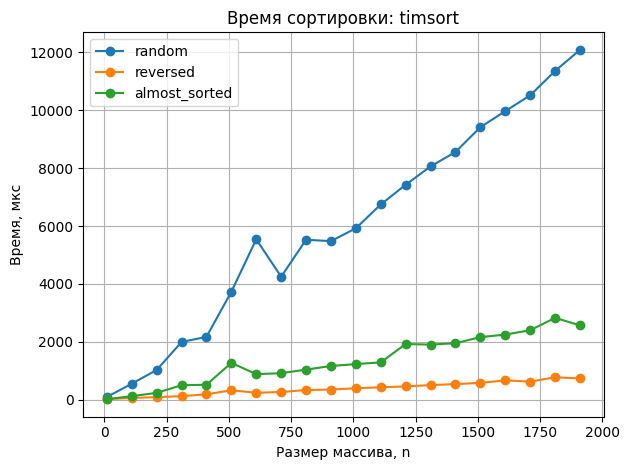

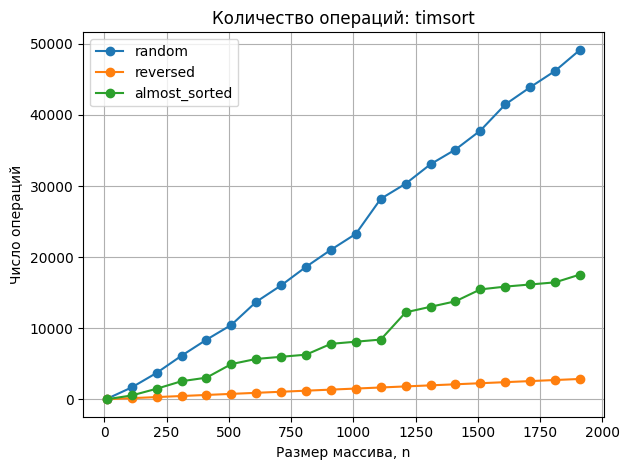

In [29]:
alg_name = "timsort"
df_alg = df[df["algorithm"] == alg_name]

# График Время
plt.figure()
for array_type_name in df_alg["array_type"].unique():
    dfa = df_alg[df_alg["array_type"] == array_type_name]
    plt.plot(dfa["n"], dfa["time_us"], marker="o", label=array_type_name)

plt.xlabel("Размер массива, n")
plt.ylabel("Время, мкс")
plt.title(f"Время сортировки: {alg_name}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# График Операции
plt.figure()
for array_type_name in df_alg["array_type"].unique():
    dfa = df_alg[df_alg["array_type"] == array_type_name]
    plt.plot(dfa["n"], dfa["ops"], marker="o", label=array_type_name)

plt.xlabel("Размер массива, n")
plt.ylabel("Число операций")
plt.title(f"Количество операций: {alg_name}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# **Выводы:**

В отличие от классических алгоритмов, для Timsort худшим случаем являются полностью хаотичные данные (random), а обратно отсортированный массив (reversed) обрабатывается за линейное время благодаря механизму переворота убывающих ранов.



# 3. Описать асимптотику, какая она в каком случае.

**1. Обратно отсортированный массив (reversed):**

Временная сложность: О(n) — линейная (то есть по сути это лучший случай).

Получается что, когда алгоритм начинает работу, функция find_run за один проход (выполняя всего n-1 сравнений) находит, что весь массив является одним строго убывающим участком. Сразу после этого вызывается функция reverse_range, которая за n/2 операций обмена разворачивает этот участок прямо на месте. В стек runs добавляется всего один ран длиной n. Условия цикла merge_collapse и финального force_merge_all мгновенно завершаются, так как сливать один ран не с чем.



**2. Почти отсортированный массив (almost_sorted)**

Временная сложность: О(n) — близкая к линейной (средний случай)

В ходе эксперимента было замечено, что график для почти отсортированного массива (almost_sorted) имеет небольшую сверхлинейную траекторию и не является чистым O(n). Это объясняется тем, что при генерации данных количество случайных возмущений (сломанных элементов) росло пропорционально размеру массива.

Это привело к росту числа подмассивов (runs) и заставило алгоритм выполнять их слияние, асимптотика которого составляет O(nlogn). Однако за счет высокой сохранности исходного порядка константа алгоритма в этом случае минимальна, что делает его визуально близким к линейному и гораздо более эффективным, чем случайный массив.

**3. Случайный массив (random)**

Временная сложность: О(nlogn) — логарифмически-линейная (худший случай).

В хаотичных данных средняя длина естественного рана (по возрастанию или убыванию) очень маленькая (около 2 элементов).  Поскольку это гораздо меньше установленного минимума MIN_MERGE (в коде это 4, на практике обычно 32), алгоритм вынужден для каждого шага запускать binary_insertion_sort, чтобы искусственно дотягивать каждый мелкий ран до размера min_run.

Сортировка вставками на случайных данных работает за свои классические O(min_run^2). Для всего массива этот этап занимает O(n*min_run).
Так как min_run — константа, это O(n).

Однако затем стек заполняется огромным количеством мелких ранов одинакового размера. Функция merge_collapse начинает строить из них дерево слияний. Количество уровней этого дерева равно log(n/min_run), и на каждом уровне функция merge_runs обрабатывает суммарно n элементов, тратя память и операции на копирование во временные массивы.